# Formula 1 Business Intelligence — Exploratory Analysis

This notebook profiles the historical dataset and produces portfolio-ready analytical views before Tableau.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..')
RAW = ROOT / 'data' / 'raw'


In [2]:
races = pd.read_csv(RAW / 'races.csv', na_values='\\N')
results = pd.read_csv(RAW / 'results.csv', na_values='\\N')
drivers = pd.read_csv(RAW / 'drivers.csv', na_values='\\N')
constructors = pd.read_csv(RAW / 'constructors.csv', na_values='\\N')

print('Races:', races.shape)
print('Results:', results.shape)
print('Drivers:', drivers.shape)
print('Constructors:', constructors.shape)


Races: (1125, 18)
Results: (26759, 18)
Drivers: (861, 9)
Constructors: (212, 5)


## Data quality snapshot


In [3]:
quality = results.isna().sum().sort_values(ascending=False)
quality[quality > 0]


milliseconds       19079
time               19079
fastestLapSpeed    18507
fastestLapTime     18507
fastestLap         18507
rank               18249
position           10953
number                 6
dtype: int64

## Unique winners by season


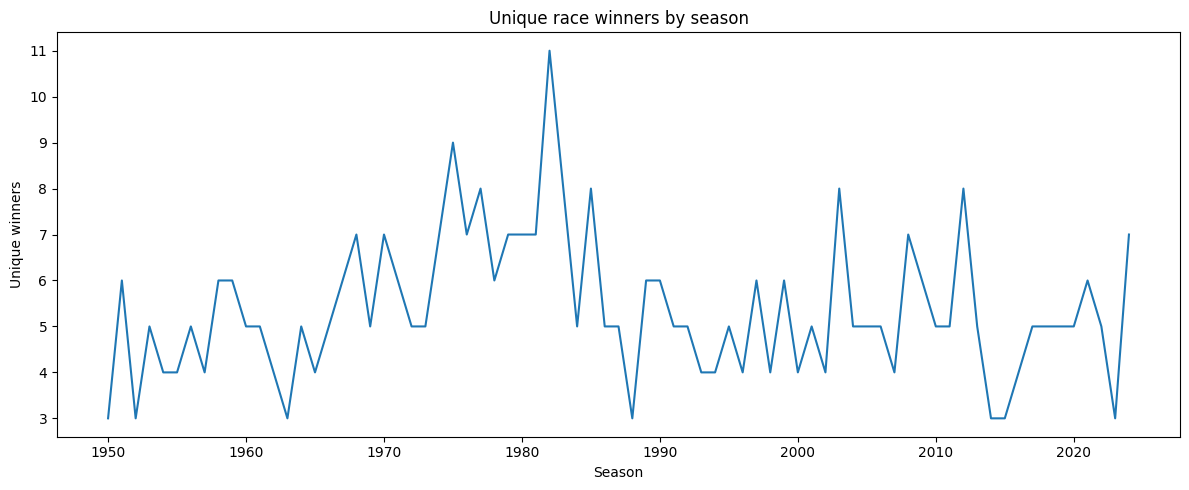

In [4]:
winner_rows = results.merge(races[['raceId','year']], on='raceId')
winners = (winner_rows[winner_rows['positionOrder'] == 1]
           .groupby('year')['driverId'].nunique()
           .reset_index(name='unique_winners'))

plt.figure(figsize=(12,5))
plt.plot(winners['year'], winners['unique_winners'])
plt.title('Unique race winners by season')
plt.xlabel('Season')
plt.ylabel('Unique winners')
plt.tight_layout()
plt.show()


## Driver position gain


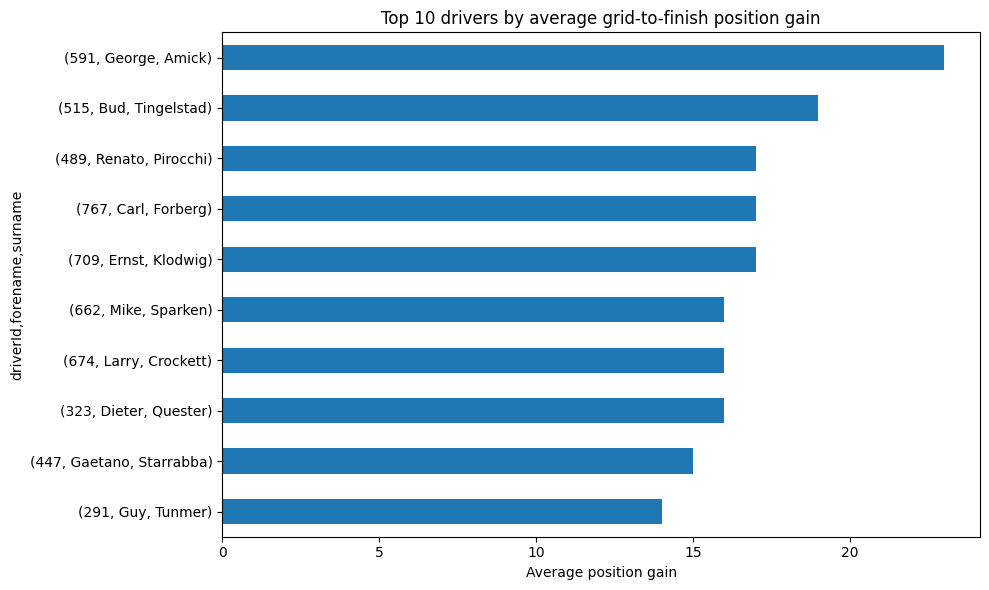

In [5]:
driver = results.merge(drivers[['driverId','forename','surname']], on='driverId')
driver['position_gain'] = driver['grid'] - driver['positionOrder']

top_gain = (driver[(driver['grid'] > 0) & (driver['positionOrder'] > 0)]
             .groupby(['driverId','forename','surname'])['position_gain']
             .mean()
             .sort_values(ascending=False)
             .head(10)
             .sort_values())

plt.figure(figsize=(10,6))
top_gain.plot(kind='barh')
plt.title('Top 10 drivers by average grid-to-finish position gain')
plt.xlabel('Average position gain')
plt.tight_layout()
plt.show()


## Constructor points over time


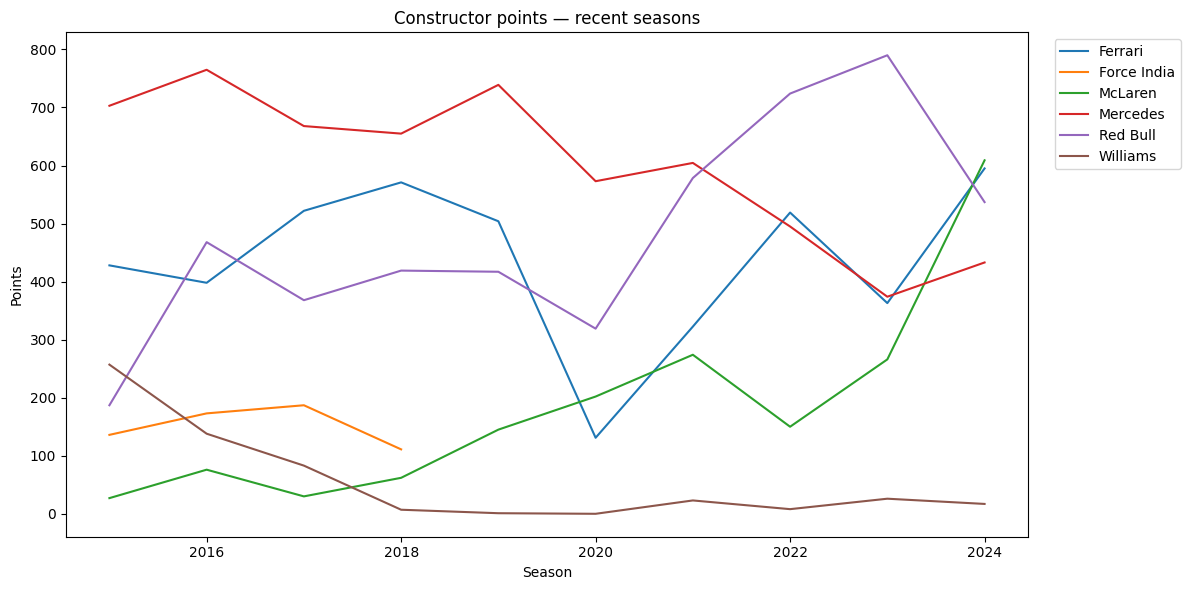

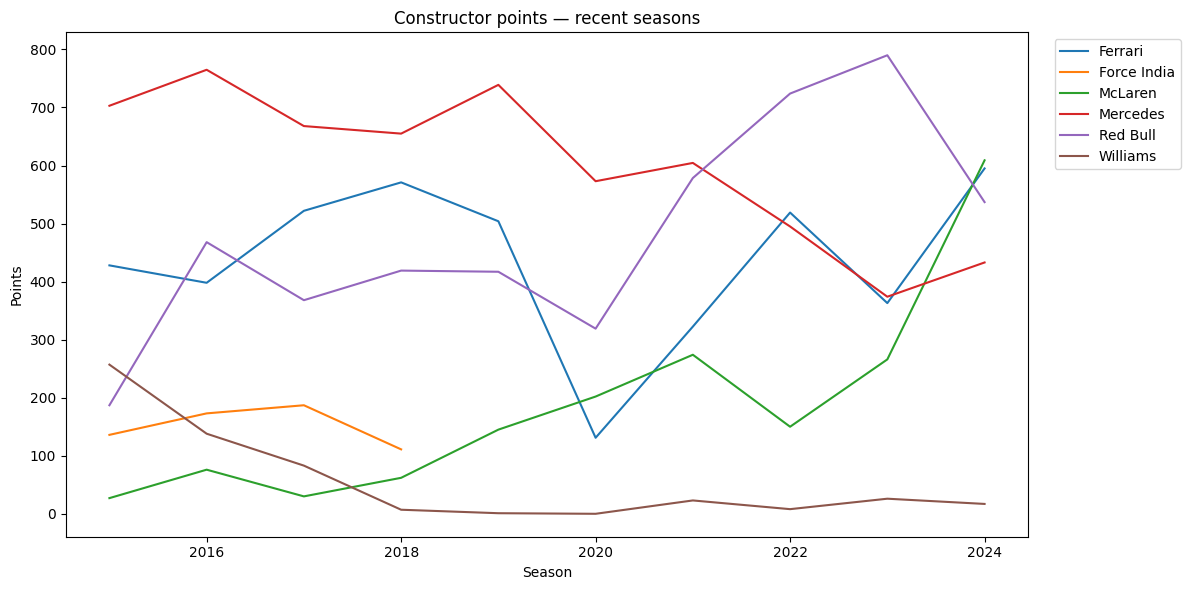

In [6]:
constructor = (
    results
    .merge(races[['raceId', 'year']], on='raceId')
    .merge(
        constructors[['constructorId', 'name']],
        on='constructorId'
    )
)

season_constructor = (
    constructor
    .groupby(['year', 'name'])['points']
    .sum()
    .reset_index()
)

recent = season_constructor[
    season_constructor['year'] >= season_constructor['year'].max() - 9
]

plt.figure(figsize=(12, 6))

for name, group in recent.groupby('name'):
    if group['points'].sum() > 500:
        plt.plot(
            group['year'],
            group['points'],
            label=name
        )

plt.title('Constructor points — recent seasons')
plt.xlabel('Season')
plt.ylabel('Points')
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

recent = season_constructor[season_constructor['year'] >= season_constructor['year'].max()-9]

plt.figure(figsize=(12,6))
for name, group in recent.groupby('name'):
    if group['points'].sum() > 500:
        plt.plot(group['year'], group['points'], label=name)
plt.title('Constructor points — recent seasons')
plt.xlabel('Season')
plt.ylabel('Points')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [7]:
%whos

Variable             Type         Data/Info
-------------------------------------------
Path                 type         <class 'pathlib.Path'>
RAW                  PosixPath    ../data/raw
ROOT                 PosixPath    ..
constructor          DataFrame           resultId  raceId  <...>[26759 rows x 20 columns]
constructors         DataFrame         constructorId constr<...>n\n[212 rows x 5 columns]
driver               DataFrame           resultId  raceId  <...>[26759 rows x 21 columns]
drivers              DataFrame         driverId   driverRef<...>n\n[861 rows x 9 columns]
group                DataFrame          year      name  poi<...>0  2024  Williams    17.0
name                 str          Williams
np                   module       <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
pd                   module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt                  module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
quality  